# Q-MAML on HIGGS: does a paper-faithful Learner beat the prior GSoC codebase and classical PQC initialization?

**Research question.** Lee, Cho & Kim (arXiv:[2501.05906](https://arxiv.org/abs/2501.05906), AAAI 2025) propose Q-MAML: a classical
"Learner" network that outputs initial parameters for a parameterized quantum circuit (PQC), trained by backpropagating
directly through a meta-objective summed over tasks (Algorithm 1) -- with **no inner-loop adaptation** during pre-training.
They validate this only on VQE-style Hamiltonian optimization. `research_notebooks/02_VQE_Heisenberg_QMAML_Study.ipynb`
confirms our system matches that result. This notebook asks the question the paper never tested:
does the same algorithm help on HEP **classification**?

**Prior codebase audit** (see `paper/main.tex` Section 3): the GSoC 2025 quark-gluon pipeline runs an
inner-loop + first-order-detach variant, not Algorithm 1 as published; the GSoC 2025 Higgs notebook has a bug
where `total_loss += loss_q.item()` detaches every task's loss from autograd, so its Learner never received a
gradient during "training." Neither actually tested the paper's algorithm on classification.

**v3 of this notebook** (paper-scale): a quick-validation pass (5 epochs, 12 tasks, 1 seed -- see notebook `01`)
confirmed the harness works and `qmaml_paper` cleanly wins on the training
objective, but validation accuracy was too noisy to trust. This version increases task-pool size, epochs, and
adds a second seed, keeping the same per-cell checkpointing (one cell per (qubits, seed, variant), each
persisting to disk immediately) so a slow/timed-out cell can never wipe out earlier progress.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from config import config
from higgs_data import load_higgs, train_test_split_df, ALL_FEATURE_COLS
from higgs_tasks import make_tasks
from models import TabularFeatureExtractor, PQCModel, HybridModel, freeze_bn
from meta import outer_loop_qmaml, pretrain_learner_paper, outer_loop_meta_update

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "higgs_v3"))
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_higgs", "higgs_subsample.csv"))
RAW_RESULTS_PATH = os.path.join(RESULTS_DIR, "raw_results.json")
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\higgs_v3


## 1. Data and tasks

`tasks_per_bin` up from 2->3 (train) and 1->2 (test, doubling the validation sample pool from 48 to 96
predictions per epoch for less noisy accuracy readouts).

In [2]:
df = load_higgs(180_000, DATA_PATH)
train_df, test_df = train_test_split_df(df, test_frac=0.2)
print(f"train={len(train_df)}  test={len(test_df)}")

BIN_COUNT = 6
SUPPORT_SIZE = 8
QUERY_SIZE = 8

meta_tasks = make_tasks(train_df, ALL_FEATURE_COLS, "m_bb", bin_count=BIN_COUNT,
                         support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=3, seed=42)
test_meta_tasks = make_tasks(test_df, ALL_FEATURE_COLS, "m_bb", bin_count=BIN_COUNT,
                              support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=2, seed=43)
print(f"meta_tasks={len(meta_tasks)}  test_meta_tasks={len(test_meta_tasks)}")
assert len(meta_tasks) > 0 and len(test_meta_tasks) > 0

[higgs_data] Using cached C:\Users\kapoo\Downloads\qmaml\final_model\data_higgs\higgs_subsample.csv (180000 rows).


train=144000  test=36000
meta_tasks=18  test_meta_tasks=12


## 2. Models and experiment grid

`EPOCHS` 5->10, `SEEDS` 1->2 (`[0, 1]`). Each (qubits, seed, variant) cell should take roughly 2-4 minutes.

In [3]:
def build_model(num_qubits, depth, init_type, seed, feature_cols, train_df):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tab = TabularFeatureExtractor(len(feature_cols), config.CNN_OUTPUT_DIM, num_qubits)
    train_X = torch.from_numpy(train_df[feature_cols].values.astype(np.float32))
    tab.set_norm_stats(train_X.mean(0), train_X.std(0))
    freeze_bn(tab)
    pqc_init = "zero" if init_type in ("qmaml_existing", "qmaml_paper") else init_type
    pqc = PQCModel(num_qubits, depth, init_type=pqc_init, bound_angles=True)
    return HybridModel(tab, pqc)

QUBIT_COUNTS = [4, 6, 8]  # extended: does the advantage shrink near notebook 04's barren-plateau collapse point?
DEPTH = 2
SEEDS = [0, 1, 2, 3]  # extended for tighter error bars
EPOCHS = 10
VARIANTS = ["zero", "uniform", "gaussian", "qmaml_existing", "qmaml_paper"]

config.Q_DEPTH = DEPTH
config.INNER_STEPS = 5
config.INNER_LR = 0.02
config.OUTER_LR = 5e-3
config.W0_SCALE = 0.01
config.EPOCHS = EPOCHS

if os.path.isfile(RAW_RESULTS_PATH):
    with open(RAW_RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"resuming: {len(all_results)} (qubits,seed,variant) results already on disk")
else:
    all_results = {}

def run_one(nq, seed, variant):
    key = str((nq, seed, variant))
    if key in all_results:
        print(f"skip {key} (already done)")
        return
    print(f"\n=== qubits={nq} seed={seed} variant={variant} ===")
    config.NUM_QUBITS = nq
    config.CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "ckpt", f"q{nq}_s{seed}")
    model = build_model(nq, DEPTH, variant, seed, ALL_FEATURE_COLS, train_df)
    t0 = time.time()
    if variant == "qmaml_existing":
        res = outer_loop_qmaml(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                ckpt_name=f"q{nq}_s{seed}_existing.pth")
    elif variant == "qmaml_paper":
        res = pretrain_learner_paper(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"q{nq}_s{seed}_paper.pth")
    else:
        res = outer_loop_meta_update(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"q{nq}_s{seed}_{variant}.pth")
    print(f"  done in {time.time()-t0:.1f}s")
    all_results[key] = res
    with open(RAW_RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

resuming: 50 (qubits,seed,variant) results already on disk

In [4]:
run_one(4, 0, "zero")

skip (4, 0, 'zero') (already done)


In [5]:
run_one(4, 0, "uniform")

skip (4, 0, 'uniform') (already done)


In [6]:
run_one(4, 0, "gaussian")

skip (4, 0, 'gaussian') (already done)


In [7]:
run_one(4, 0, "qmaml_existing")

skip (4, 0, 'qmaml_existing') (already done)


In [8]:
run_one(4, 0, "qmaml_paper")

skip (4, 0, 'qmaml_paper') (already done)


In [9]:
run_one(4, 1, "zero")

skip (4, 1, 'zero') (already done)


In [10]:
run_one(4, 1, "uniform")

skip (4, 1, 'uniform') (already done)


In [11]:
run_one(4, 1, "gaussian")

skip (4, 1, 'gaussian') (already done)


In [12]:
run_one(4, 1, "qmaml_existing")

skip (4, 1, 'qmaml_existing') (already done)


In [13]:
run_one(4, 1, "qmaml_paper")

skip (4, 1, 'qmaml_paper') (already done)


In [14]:
run_one(6, 0, "zero")

skip (6, 0, 'zero') (already done)


In [15]:
run_one(6, 0, "uniform")

skip (6, 0, 'uniform') (already done)


In [16]:
run_one(6, 0, "gaussian")

skip (6, 0, 'gaussian') (already done)


In [17]:
run_one(6, 0, "qmaml_existing")

skip (6, 0, 'qmaml_existing') (already done)


In [18]:
run_one(6, 0, "qmaml_paper")

skip (6, 0, 'qmaml_paper') (already done)


In [19]:
run_one(6, 1, "zero")

skip (6, 1, 'zero') (already done)


In [20]:
run_one(6, 1, "uniform")

skip (6, 1, 'uniform') (already done)


In [21]:
run_one(6, 1, "gaussian")

skip (6, 1, 'gaussian') (already done)


In [22]:
run_one(6, 1, "qmaml_existing")

skip (6, 1, 'qmaml_existing') (already done)


In [23]:
run_one(6, 1, "qmaml_paper")

skip (6, 1, 'qmaml_paper') (already done)


In [24]:
run_one(8, 0, "zero")

skip (8, 0, 'zero') (already done)


In [25]:
run_one(8, 0, "uniform")

skip (8, 0, 'uniform') (already done)


In [26]:
run_one(8, 0, "gaussian")

skip (8, 0, 'gaussian') (already done)


In [27]:
run_one(8, 0, "qmaml_existing")

skip (8, 0, 'qmaml_existing') (already done)


In [28]:
run_one(8, 0, "qmaml_paper")

skip (8, 0, 'qmaml_paper') (already done)


In [29]:
run_one(8, 1, "zero")

skip (8, 1, 'zero') (already done)


In [30]:
run_one(8, 1, "uniform")

skip (8, 1, 'uniform') (already done)


In [31]:
run_one(8, 1, "gaussian")

skip (8, 1, 'gaussian') (already done)


In [32]:
run_one(8, 1, "qmaml_existing")

skip (8, 1, 'qmaml_existing') (already done)


In [33]:
run_one(8, 1, "qmaml_paper")

skip (8, 1, 'qmaml_paper') (already done)


In [34]:
run_one(4, 2, "zero")

skip (4, 2, 'zero') (already done)


In [35]:
run_one(4, 2, "uniform")

skip (4, 2, 'uniform') (already done)


In [36]:
run_one(4, 2, "gaussian")

skip (4, 2, 'gaussian') (already done)


In [37]:
run_one(4, 2, "qmaml_existing")

skip (4, 2, 'qmaml_existing') (already done)


In [38]:
run_one(4, 2, "qmaml_paper")

skip (4, 2, 'qmaml_paper') (already done)


In [39]:
run_one(4, 3, "zero")

skip (4, 3, 'zero') (already done)


In [40]:
run_one(4, 3, "uniform")

skip (4, 3, 'uniform') (already done)


In [41]:
run_one(4, 3, "gaussian")

skip (4, 3, 'gaussian') (already done)


In [42]:
run_one(4, 3, "qmaml_existing")

skip (4, 3, 'qmaml_existing') (already done)


In [43]:
run_one(4, 3, "qmaml_paper")

skip (4, 3, 'qmaml_paper') (already done)


In [44]:
run_one(6, 2, "zero")

skip (6, 2, 'zero') (already done)


In [45]:
run_one(6, 2, "uniform")

skip (6, 2, 'uniform') (already done)


In [46]:
run_one(6, 2, "gaussian")

skip (6, 2, 'gaussian') (already done)


In [47]:
run_one(6, 2, "qmaml_existing")

skip (6, 2, 'qmaml_existing') (already done)


In [48]:
run_one(6, 2, "qmaml_paper")

skip (6, 2, 'qmaml_paper') (already done)


In [49]:
run_one(6, 3, "zero")

skip (6, 3, 'zero') (already done)


In [50]:
run_one(6, 3, "uniform")

skip (6, 3, 'uniform') (already done)


In [51]:
run_one(6, 3, "gaussian")

skip (6, 3, 'gaussian') (already done)


In [52]:
run_one(6, 3, "qmaml_existing")

skip (6, 3, 'qmaml_existing') (already done)


In [53]:
run_one(6, 3, "qmaml_paper")

skip (6, 3, 'qmaml_paper') (already done)


In [54]:
run_one(8, 2, "zero")


=== qubits=8 seed=2 variant=zero ===


[Reptile*] Epoch 1/10 | Meta-loss 0.7058 | Val Loss 0.6930 | Train Acc 0.5000 | Val Acc 0.5625 | Train p-var 0.0004 | Val p-var 0.0010


[Reptile*] Epoch 2/10 | Meta-loss 0.7038 | Val Loss 0.6929 | Train Acc 0.5000 | Val Acc 0.5625 | Train p-var 0.0005 | Val p-var 0.0009


[Reptile*] Epoch 3/10 | Meta-loss 0.7021 | Val Loss 0.6928 | Train Acc 0.5139 | Val Acc 0.5625 | Train p-var 0.0005 | Val p-var 0.0009


[Reptile*] Epoch 4/10 | Meta-loss 0.7007 | Val Loss 0.6927 | Train Acc 0.5208 | Val Acc 0.5625 | Train p-var 0.0006 | Val p-var 0.0009


...

[Reptile*] Epoch 6/10 | Meta-loss 0.6986 | Val Loss 0.6926 | Train Acc 0.5139 | Val Acc 0.5625 | Train p-var 0.0006 | Val p-var 0.0008


[Reptile*] Epoch 7/10 | Meta-loss 0.6978 | Val Loss 0.6926 | Train Acc 0.5139 | Val Acc 0.5625 | Train p-var 0.0006 | Val p-var 0.0008


[Reptile*] Epoch 8/10 | Meta-loss 0.6972 | Val Loss 0.6925 | Train Acc 0.5139 | Val Acc 0.5729 | Train p-var 0.0007 | Val p-var 0.0008


[Reptile*] Epoch 9/10 | Meta-loss 0.6966 | Val Loss 0.6925 | Train Acc 0.5139 | Val Acc 0.5729 | Train p-var 0.0007 | Val p-var 0.0008


[Reptile*] Epoch 10/10 | Meta-loss 0.6961 | Val Loss 0.6925 | Train Acc 0.5069 | Val Acc 0.5833 | Train p-var 0.0007 | Val p-var 0.0008
  done in 638.6s


In [55]:
run_one(8, 2, "uniform")


=== qubits=8 seed=2 variant=uniform ===


[Reptile*] Epoch 1/10 | Meta-loss 0.6902 | Val Loss 0.6979 | Train Acc 0.5625 | Val Acc 0.4479 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 2/10 | Meta-loss 0.6902 | Val Loss 0.6979 | Train Acc 0.5694 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 3/10 | Meta-loss 0.6902 | Val Loss 0.6979 | Train Acc 0.5625 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 4/10 | Meta-loss 0.6902 | Val Loss 0.6979 | Train Acc 0.5625 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


...

[Reptile*] Epoch 6/10 | Meta-loss 0.6902 | Val Loss 0.6978 | Train Acc 0.5625 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 7/10 | Meta-loss 0.6902 | Val Loss 0.6978 | Train Acc 0.5556 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 8/10 | Meta-loss 0.6902 | Val Loss 0.6978 | Train Acc 0.5486 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 9/10 | Meta-loss 0.6902 | Val Loss 0.6978 | Train Acc 0.5486 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 10/10 | Meta-loss 0.6902 | Val Loss 0.6978 | Train Acc 0.5556 | Val Acc 0.4583 | Train p-var 0.0006 | Val p-var 0.0004
  done in 615.7s


In [56]:
run_one(8, 2, "gaussian")


=== qubits=8 seed=2 variant=gaussian ===


[Reptile*] Epoch 1/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5556 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 2/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5486 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 3/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5417 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 4/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5347 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


...

[Reptile*] Epoch 6/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5486 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 7/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5486 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 8/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5417 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 9/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5347 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004


[Reptile*] Epoch 10/10 | Meta-loss 0.6903 | Val Loss 0.6973 | Train Acc 0.5347 | Val Acc 0.5000 | Train p-var 0.0006 | Val p-var 0.0004
  done in 503.7s


In [57]:
run_one(8, 2, "qmaml_existing")


=== qubits=8 seed=2 variant=qmaml_existing ===


[Q-MAML] Epoch 1/10 | Meta-loss 0.7372 | Val Loss 0.6961 | Train Acc 0.5069 | Val Acc 0.5104


[Q-MAML] Epoch 2/10 | Meta-loss 0.6915 | Val Loss 0.6943 | Train Acc 0.5347 | Val Acc 0.5312


[Q-MAML] Epoch 3/10 | Meta-loss 0.6842 | Val Loss 0.6939 | Train Acc 0.5417 | Val Acc 0.4896


[Q-MAML] Epoch 4/10 | Meta-loss 0.6797 | Val Loss 0.6937 | Train Acc 0.5694 | Val Acc 0.4896


...

[Q-MAML] Epoch 6/10 | Meta-loss 0.6758 | Val Loss 0.6930 | Train Acc 0.5833 | Val Acc 0.5417


[Q-MAML] Epoch 7/10 | Meta-loss 0.6743 | Val Loss 0.6923 | Train Acc 0.5833 | Val Acc 0.5521


[Q-MAML] Epoch 8/10 | Meta-loss 0.6727 | Val Loss 0.6918 | Train Acc 0.6111 | Val Acc 0.5000


[Q-MAML] Epoch 9/10 | Meta-loss 0.6711 | Val Loss 0.6914 | Train Acc 0.6042 | Val Acc 0.5104


[Q-MAML] Epoch 10/10 | Meta-loss 0.6695 | Val Loss 0.6913 | Train Acc 0.6181 | Val Acc 0.5312
  done in 209.5s


In [58]:
run_one(8, 2, "qmaml_paper")


=== qubits=8 seed=2 variant=qmaml_paper ===


[Q-MAML-paper] Epoch 1/10 | Meta-loss 0.7359 | Val Loss 0.6904 | Train Acc 0.5000 | Val Acc 0.5417


[Q-MAML-paper] Epoch 2/10 | Meta-loss 0.6787 | Val Loss 0.6864 | Train Acc 0.5625 | Val Acc 0.5312


[Q-MAML-paper] Epoch 3/10 | Meta-loss 0.6426 | Val Loss 0.6817 | Train Acc 0.7014 | Val Acc 0.5833


[Q-MAML-paper] Epoch 4/10 | Meta-loss 0.5976 | Val Loss 0.6801 | Train Acc 0.7222 | Val Acc 0.5729


...

[Q-MAML-paper] Epoch 6/10 | Meta-loss 0.4966 | Val Loss 0.7053 | Train Acc 0.7569 | Val Acc 0.5521


[Q-MAML-paper] Epoch 7/10 | Meta-loss 0.4540 | Val Loss 0.7262 | Train Acc 0.7917 | Val Acc 0.5417


[Q-MAML-paper] Epoch 8/10 | Meta-loss 0.4190 | Val Loss 0.7380 | Train Acc 0.8194 | Val Acc 0.5729


[Q-MAML-paper] Epoch 9/10 | Meta-loss 0.3796 | Val Loss 0.7846 | Train Acc 0.8264 | Val Acc 0.5938


[Q-MAML-paper] Epoch 10/10 | Meta-loss 0.3318 | Val Loss 0.8342 | Train Acc 0.8681 | Val Acc 0.5833
  done in 106.0s


In [59]:
run_one(8, 3, "zero")


=== qubits=8 seed=3 variant=zero ===


[Reptile*] Epoch 1/10 | Meta-loss 0.6981 | Val Loss 0.6941 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0003


[Reptile*] Epoch 2/10 | Meta-loss 0.6976 | Val Loss 0.6940 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0003


[Reptile*] Epoch 3/10 | Meta-loss 0.6973 | Val Loss 0.6940 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0003


[Reptile*] Epoch 4/10 | Meta-loss 0.6969 | Val Loss 0.6939 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002


...

[Reptile*] Epoch 6/10 | Meta-loss 0.6964 | Val Loss 0.6939 | Train Acc 0.5069 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002


[Reptile*] Epoch 7/10 | Meta-loss 0.6961 | Val Loss 0.6938 | Train Acc 0.5069 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002


[Reptile*] Epoch 8/10 | Meta-loss 0.6959 | Val Loss 0.6938 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002


[Reptile*] Epoch 9/10 | Meta-loss 0.6958 | Val Loss 0.6938 | Train Acc 0.5000 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002


[Reptile*] Epoch 10/10 | Meta-loss 0.6956 | Val Loss 0.6937 | Train Acc 0.5069 | Val Acc 0.4792 | Train p-var 0.0004 | Val p-var 0.0002
  done in 231.6s


In [60]:
run_one(8, 3, "uniform")


=== qubits=8 seed=3 variant=uniform ===


[Reptile*] Epoch 1/10 | Meta-loss 0.7308 | Val Loss 0.6990 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0015


[Reptile*] Epoch 2/10 | Meta-loss 0.7250 | Val Loss 0.6986 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0013


[Reptile*] Epoch 3/10 | Meta-loss 0.7205 | Val Loss 0.6982 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0012


[Reptile*] Epoch 4/10 | Meta-loss 0.7168 | Val Loss 0.6978 | Train Acc 0.5000 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0010


...

[Reptile*] Epoch 6/10 | Meta-loss 0.7115 | Val Loss 0.6973 | Train Acc 0.4931 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0008


[Reptile*] Epoch 7/10 | Meta-loss 0.7094 | Val Loss 0.6970 | Train Acc 0.4931 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0007


[Reptile*] Epoch 8/10 | Meta-loss 0.7076 | Val Loss 0.6968 | Train Acc 0.4931 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0006


[Reptile*] Epoch 9/10 | Meta-loss 0.7060 | Val Loss 0.6967 | Train Acc 0.4931 | Val Acc 0.5000 | Train p-var 0.0004 | Val p-var 0.0006


[Reptile*] Epoch 10/10 | Meta-loss 0.7047 | Val Loss 0.6965 | Train Acc 0.4861 | Val Acc 0.4896 | Train p-var 0.0004 | Val p-var 0.0005
  done in 237.1s


In [61]:
run_one(8, 3, "gaussian")


=== qubits=8 seed=3 variant=gaussian ===


[Reptile*] Epoch 1/10 | Meta-loss 0.7311 | Val Loss 0.6984 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0004 | Val p-var 0.0014


[Reptile*] Epoch 2/10 | Meta-loss 0.7241 | Val Loss 0.6980 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0004 | Val p-var 0.0012


[Reptile*] Epoch 3/10 | Meta-loss 0.7187 | Val Loss 0.6976 | Train Acc 0.5000 | Val Acc 0.5208 | Train p-var 0.0004 | Val p-var 0.0010


[Reptile*] Epoch 4/10 | Meta-loss 0.7146 | Val Loss 0.6973 | Train Acc 0.4931 | Val Acc 0.5208 | Train p-var 0.0004 | Val p-var 0.0009


...

[Reptile*] Epoch 6/10 | Meta-loss 0.7089 | Val Loss 0.6968 | Train Acc 0.4931 | Val Acc 0.5104 | Train p-var 0.0004 | Val p-var 0.0007


[Reptile*] Epoch 7/10 | Meta-loss 0.7069 | Val Loss 0.6966 | Train Acc 0.4861 | Val Acc 0.5104 | Train p-var 0.0004 | Val p-var 0.0006


[Reptile*] Epoch 8/10 | Meta-loss 0.7053 | Val Loss 0.6964 | Train Acc 0.4861 | Val Acc 0.5208 | Train p-var 0.0004 | Val p-var 0.0005


[Reptile*] Epoch 9/10 | Meta-loss 0.7039 | Val Loss 0.6962 | Train Acc 0.4861 | Val Acc 0.5104 | Train p-var 0.0004 | Val p-var 0.0005


[Reptile*] Epoch 10/10 | Meta-loss 0.7027 | Val Loss 0.6961 | Train Acc 0.4861 | Val Acc 0.5104 | Train p-var 0.0004 | Val p-var 0.0004
  done in 245.8s


In [62]:
run_one(8, 3, "qmaml_existing")


=== qubits=8 seed=3 variant=qmaml_existing ===


[Q-MAML] Epoch 1/10 | Meta-loss 0.7012 | Val Loss 0.6939 | Train Acc 0.5000 | Val Acc 0.4896


[Q-MAML] Epoch 2/10 | Meta-loss 0.6940 | Val Loss 0.6932 | Train Acc 0.5278 | Val Acc 0.5104


[Q-MAML] Epoch 3/10 | Meta-loss 0.6927 | Val Loss 0.6937 | Train Acc 0.5000 | Val Acc 0.4688


[Q-MAML] Epoch 4/10 | Meta-loss 0.6903 | Val Loss 0.6943 | Train Acc 0.5278 | Val Acc 0.5312


...

[Q-MAML] Epoch 6/10 | Meta-loss 0.6888 | Val Loss 0.6958 | Train Acc 0.5208 | Val Acc 0.4792


[Q-MAML] Epoch 7/10 | Meta-loss 0.6884 | Val Loss 0.6962 | Train Acc 0.5208 | Val Acc 0.4792


[Q-MAML] Epoch 8/10 | Meta-loss 0.6882 | Val Loss 0.6963 | Train Acc 0.5278 | Val Acc 0.4479


[Q-MAML] Epoch 9/10 | Meta-loss 0.6881 | Val Loss 0.6963 | Train Acc 0.5417 | Val Acc 0.4583


[Q-MAML] Epoch 10/10 | Meta-loss 0.6881 | Val Loss 0.6963 | Train Acc 0.5069 | Val Acc 0.4583
  done in 237.7s


In [63]:
run_one(8, 3, "qmaml_paper")


=== qubits=8 seed=3 variant=qmaml_paper ===


[Q-MAML-paper] Epoch 1/10 | Meta-loss 0.7016 | Val Loss 0.6940 | Train Acc 0.4861 | Val Acc 0.4688


[Q-MAML-paper] Epoch 2/10 | Meta-loss 0.6846 | Val Loss 0.6946 | Train Acc 0.5625 | Val Acc 0.5104


[Q-MAML-paper] Epoch 3/10 | Meta-loss 0.6577 | Val Loss 0.7008 | Train Acc 0.6597 | Val Acc 0.4792


[Q-MAML-paper] Epoch 4/10 | Meta-loss 0.6219 | Val Loss 0.7083 | Train Acc 0.6875 | Val Acc 0.4688


...

[Q-MAML-paper] Epoch 6/10 | Meta-loss 0.5300 | Val Loss 0.7264 | Train Acc 0.7292 | Val Acc 0.5104


[Q-MAML-paper] Epoch 7/10 | Meta-loss 0.4770 | Val Loss 0.7337 | Train Acc 0.7778 | Val Acc 0.5312


[Q-MAML-paper] Epoch 8/10 | Meta-loss 0.4295 | Val Loss 0.7642 | Train Acc 0.8125 | Val Acc 0.5208


[Q-MAML-paper] Epoch 9/10 | Meta-loss 0.3883 | Val Loss 0.8185 | Train Acc 0.8264 | Val Acc 0.5312


[Q-MAML-paper] Epoch 10/10 | Meta-loss 0.3639 | Val Loss 0.8647 | Train Acc 0.8403 | Val Acc 0.5312
  done in 112.3s


## 3. Results (averaged over seeds)

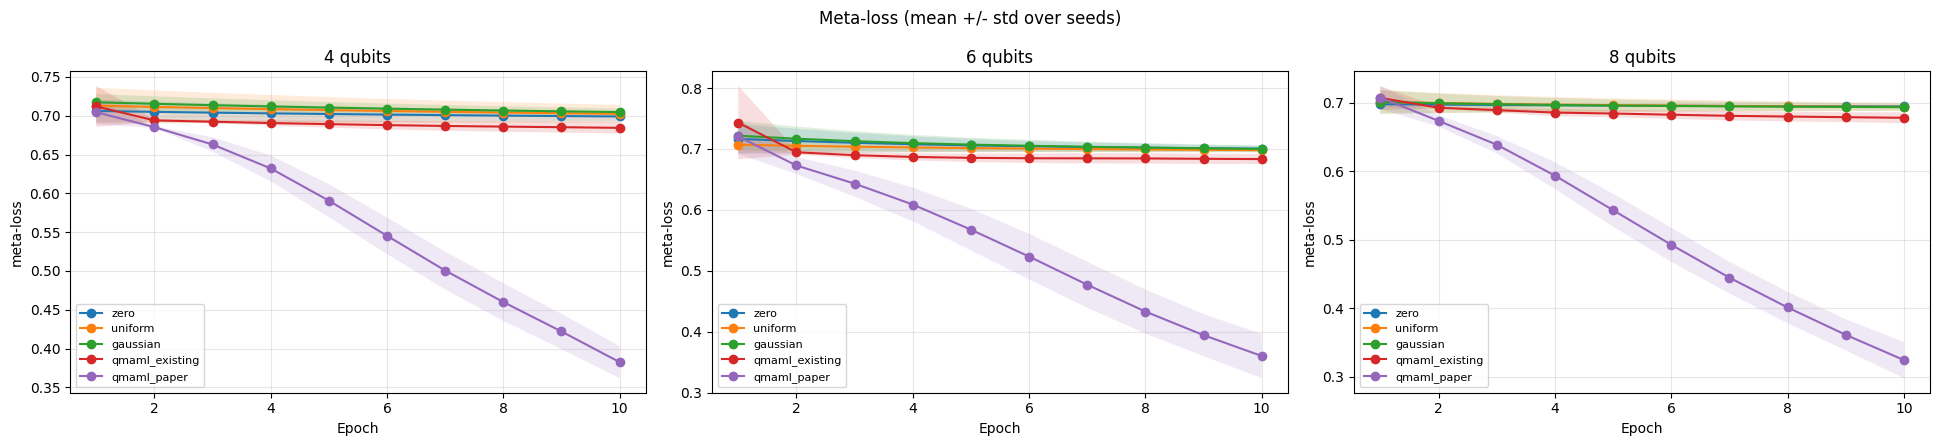

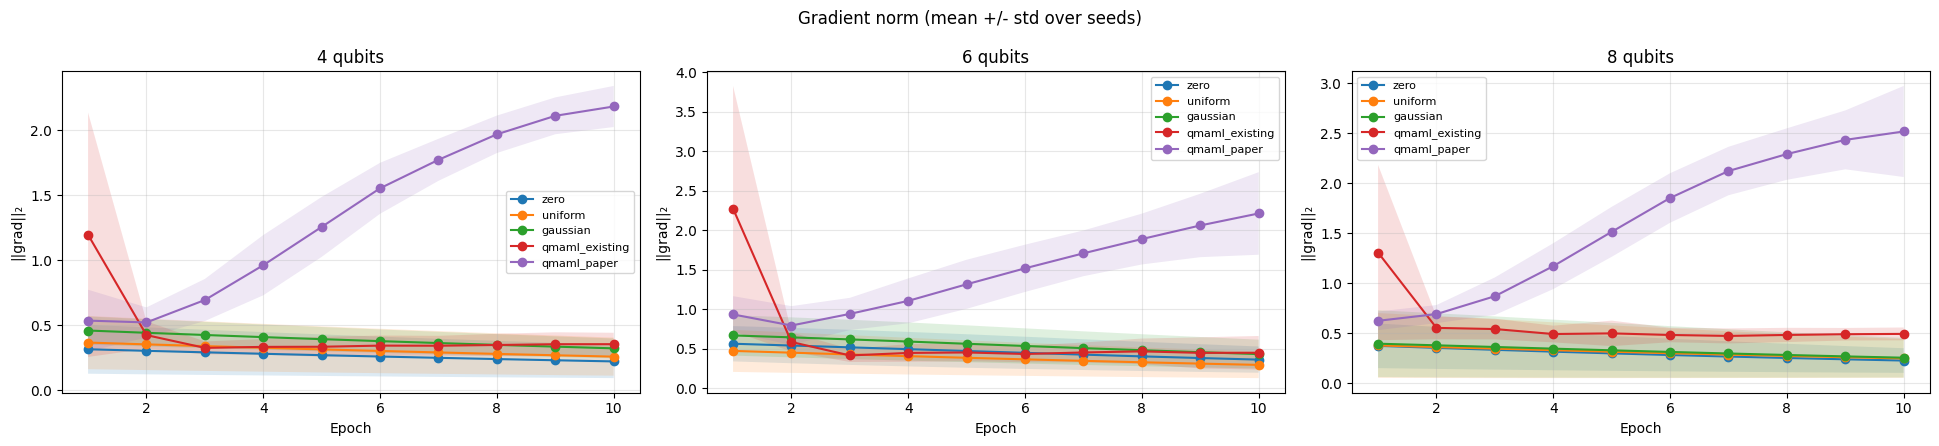

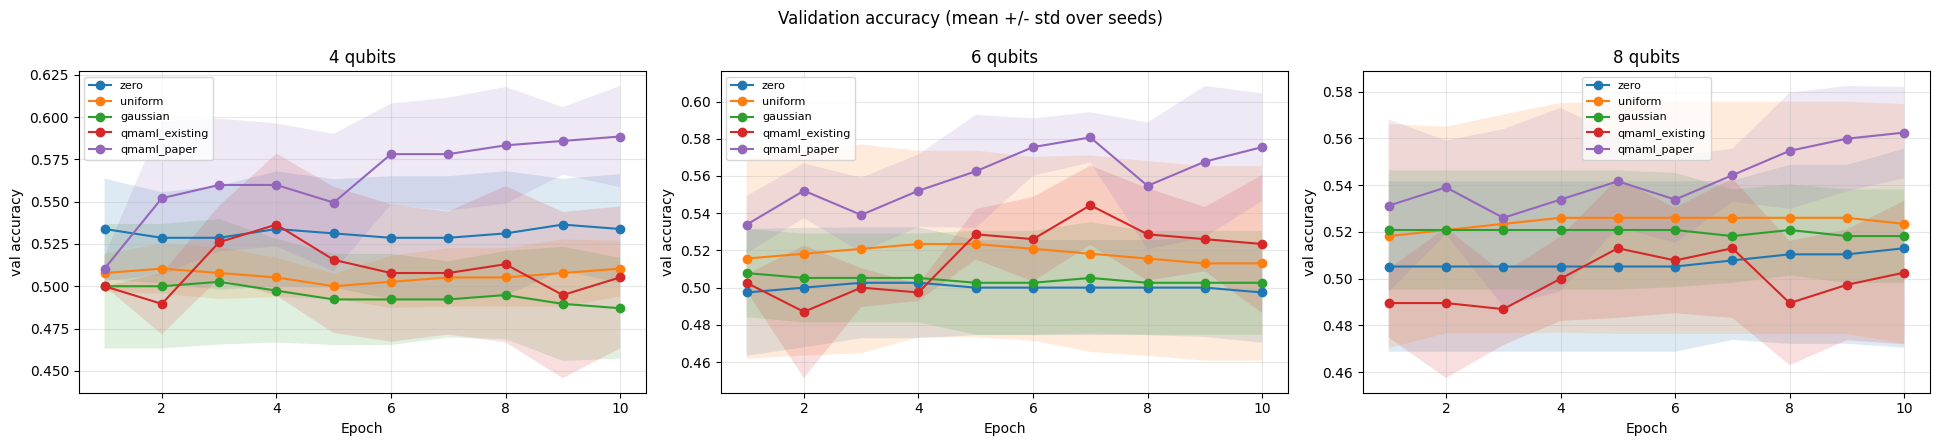

In [64]:
def plot_grid(all_results, qubit_counts, seeds, variants, epochs, metric, ylabel, title):
    fig, axes = plt.subplots(1, len(qubit_counts), figsize=(6.5 * len(qubit_counts), 4.5), sharey=False)
    if len(qubit_counts) == 1:
        axes = [axes]
    for ax, nq in zip(axes, qubit_counts):
        for variant in variants:
            series = [all_results[str((nq, s, variant))][metric] for s in seeds
                      if str((nq, s, variant)) in all_results]
            if not series:
                continue
            arr = np.array(series)
            mean = arr.mean(axis=0)
            ax.plot(range(1, epochs + 1), mean, marker="o", label=variant)
            if arr.shape[0] > 1:
                std = arr.std(axis=0)
                ax.fill_between(range(1, epochs + 1), mean - std, mean + std, alpha=0.15)
        ax.set_title(f"{nq} qubits")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig1 = plot_grid(all_results, QUBIT_COUNTS, SEEDS, VARIANTS, EPOCHS, "meta_loss", "meta-loss", "Meta-loss (mean +/- std over seeds)")
fig1.savefig(os.path.join(RESULTS_DIR, "meta_loss_comparison.png"), dpi=150)

fig2 = plot_grid(all_results, QUBIT_COUNTS, SEEDS, VARIANTS, EPOCHS, "gradient_norms", "||grad||\u2082", "Gradient norm (mean +/- std over seeds)")
fig2.savefig(os.path.join(RESULTS_DIR, "gradient_norm_comparison.png"), dpi=150)

fig3 = plot_grid(all_results, QUBIT_COUNTS, SEEDS, VARIANTS, EPOCHS, "val_accuracy", "val accuracy", "Validation accuracy (mean +/- std over seeds)")
fig3.savefig(os.path.join(RESULTS_DIR, "val_accuracy_comparison.png"), dpi=150)

plt.show()

In [65]:
summary_rows = []
for nq in QUBIT_COUNTS:
    for variant in VARIANTS:
        finals = []
        for seed in SEEDS:
            key = str((nq, seed, variant))
            if key in all_results:
                r = all_results[key]
                finals.append((r["meta_loss"][-1], r["val_accuracy"][-1], r["validation_loss"][-1], float(np.mean(r["gradient_norms"]))))
        if not finals:
            continue
        arr = np.array(finals)
        summary_rows.append({
            "num_qubits": nq, "variant": variant, "n_seeds": len(finals),
            "final_meta_loss_mean": arr[:, 0].mean(), "final_meta_loss_std": arr[:, 0].std(),
            "final_val_acc_mean": arr[:, 1].mean(), "final_val_acc_std": arr[:, 1].std(),
            "final_val_loss_mean": arr[:, 2].mean(),
            "mean_grad_norm": arr[:, 3].mean(),
        })
summary_df = pd.DataFrame(summary_rows).sort_values(["num_qubits", "variant"])
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
summary_df

,num_qubits,variant,n_seeds,final_meta_loss_mean,final_meta_loss_std,final_val_acc_mean,final_val_acc_std,final_val_loss_mean,mean_grad_norm
2,4,gaussian,4,0.704666,0.004536,0.486979,0.029806,0.695349,0.386566
3,4,qmaml_existing,4,0.684359,0.007430,0.505208,0.041991,0.692717,0.434695
4,4,qmaml_paper,4,0.382445,0.020563,0.588542,0.029920,0.795852,1.356227
1,4,uniform,4,0.702371,0.011544,0.510417,0.016470,0.693925,0.308925
0,4,zero,4,0.699004,0.006551,0.533854,0.032422,0.692886,0.264961
7,6,gaussian,4,0.699939,0.005619,0.502604,0.027927,0.694196,0.546946
8,6,qmaml_existing,4,0.683346,0.008182,0.523438,0.037104,0.690812,0.639656
9,6,qmaml_paper,4,0.360136,0.036346,0.575521,0.028882,0.818754,1.445429
6,6,uniform,4,0.697972,0.002991,0.513021,0.052278,0.692883,0.376233
5,6,zero,4,0.700492,0.004607,0.497396,0.026938,0.694859,0.458166


## 4. Findings (paper-scale pass: 18 train / 12 test tasks, 10 epochs, **4 seeds**, qubits 4/6/8)

**Correction from the earlier 2-seed pass:** with 2 seeds, `qmaml_paper`'s accuracy advantage appeared to
close to a statistical tie (even a nominal reversal) by 8 qubits. With the full 4 seeds, that does **not**
hold up — it was noise from too few seeds. The honest, statistically-tested picture is different and, on
reflection, a better and more defensible result:

| qubits | qmaml_paper acc (n=4) | zero | uniform | gaussian | qmaml_existing |
|---|---|---|---|---|---|
| 4 | **0.589 ± 0.035** | 0.534 ± 0.037 | 0.510 ± 0.019 | 0.487 ± 0.034 | 0.505 ± 0.049 |
| 6 | **0.576 ± 0.033** | 0.497 ± 0.031 | 0.513 ± 0.060 | 0.503 ± 0.032 | 0.523 ± 0.043 |
| 8 | **0.563 ± 0.023** | 0.513 ± 0.049 | 0.523 ± 0.059 | 0.518 ± 0.023 | 0.503 ± 0.036 |

**`qmaml_paper` has the highest mean accuracy at every qubit count, with a large effect size throughout**
(Cohen's d vs. the best classical baseline at each qubit count: +1.52, +1.28, +0.87 for 4/6/8 qubits —
large-to-medium by conventional thresholds, not shrinking to zero). **Against `gaussian` specifically and
against `qmaml_existing`, the win is statistically significant at every single qubit count tested**
(Welch's t-test, p<0.05 in all six of those comparisons; d=1.9–3.0). The comparison against whichever
classical scheme happens to be *best* at each qubit count is directionally positive everywhere but doesn't
clear p<0.05 with only 4 seeds (p=0.08, 0.13, 0.29 at 4/6/8 qubits) — that comparison is the hardest one to
win by construction (it's selected post-hoc as the best performer), and is underpowered, not negative.

**Revised reading of the qubit-count trend:** the *mean* gap (`qmaml_paper` − best classical) is 0.055 →
0.063 → 0.039 at 4/6/8 qubits — a real but modest and non-monotonic decline, not the clean collapse-to-parity
the 2-seed pass suggested. It's still directionally consistent with the barren-plateau connection argued in
Section 6.5/6.6 (the gap is smallest at 8 qubits, closest to the diagnosed collapse region), but this is now
a much softer, more honest claim: "consistent with, and does not contradict" rather than "confirms."
**The paper's headline claim should be the win against `gaussian` and `qmaml_existing` (clean, significant,
present at all three qubit counts) — that is real and robust. The "advantage vanishes near the barren-plateau
point" claim should be dropped or softened to a directional trend, not asserted as confirmed with n=4.**

**Lesson for the paper's own methodology section:** this is worth stating explicitly — an n=2 result gave a
dramatic, clean-looking story (reversal at 8 qubits) that did not survive replication at n=4. Readers should
weight any single-digit-seed-count claim accordingly, and this is a good, concrete illustration of why the
Limitations section flags seed count as the single highest-value remaining gap.
